# Scatter plot (Polars)
Latitude/longitude by price.

In [1]:
from get_dataset_polars import get_polars_df
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

In [2]:
# Get Polars DataFrame
raw = get_polars_df()

In [3]:
# lat/long scatter plot
# Jupyter
"""
(raw
 .sort('price')
 .plot.scatter(x='long', y='lat') # unable to get it to work with alpha=0.5, c='price', s=1
)

(raw
 .filter(pl.col('price') > 1_000_000)
 .sort('price')
 .plot.scatter(x='long', y='lat') # unable to get it to work with alpha=0.5, c='price', s=1
)
"""

"\n(raw\n .sort('price')\n .plot.scatter(x='long', y='lat') # unable to get it to work with alpha=0.5, c='price', s=1\n)\n\n(raw\n .filter(pl.col('price') > 1_000_000)\n .sort('price')\n .plot.scatter(x='long', y='lat') # unable to get it to work with alpha=0.5, c='price', s=1\n)\n"

In [4]:
# Converts Polars dataframe to Pandas for plotting
# Python IDLE equivalent
df_scatter = raw.sort('price').to_pandas()

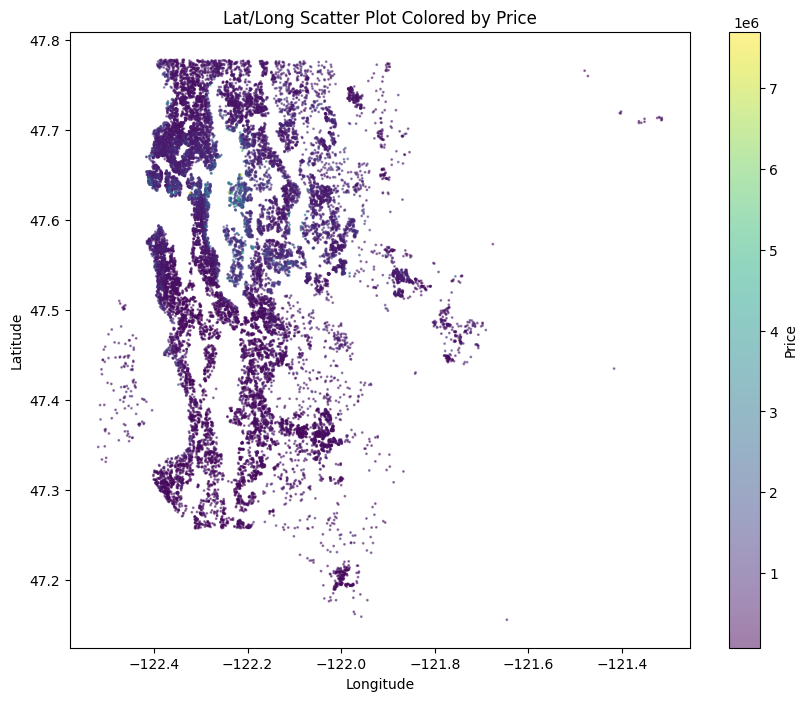

In [5]:
# --- Lat/long scatter plot (all prices) ---
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_scatter['long'], df_scatter['lat'],
                      c=df_scatter['price'], s=1, alpha=0.5, cmap='viridis')
plt.colorbar(scatter, label="Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Lat/Long Scatter Plot Colored by Price")
plt.show()

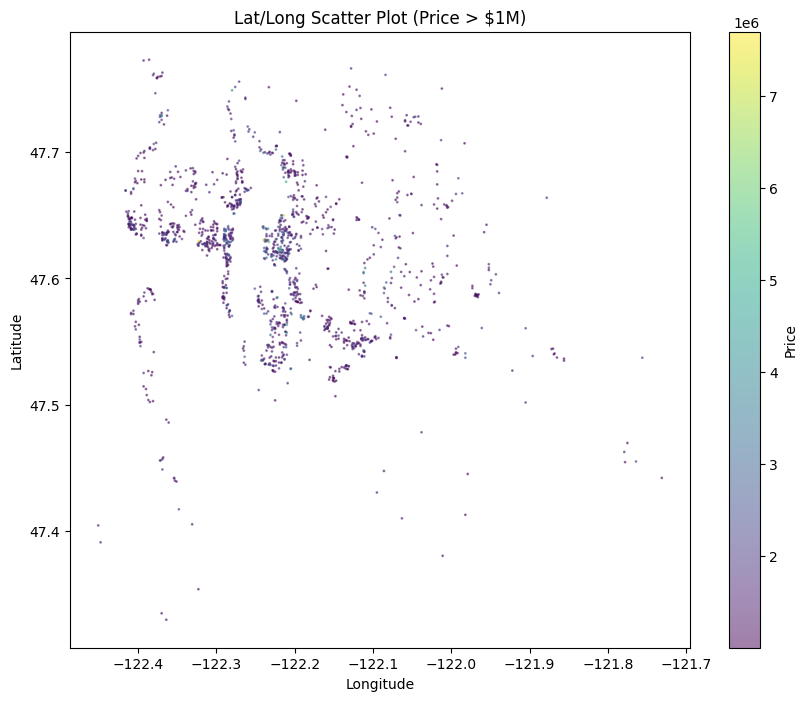

In [6]:
# --- Lat/long scatter plot (price > $1M) ---
df_high = raw.filter(pl.col('price') > 1_000_000).sort('price').to_pandas()
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_high['long'], df_high['lat'],
                      c=df_high['price'], s=1, alpha=0.5, cmap='viridis')
plt.colorbar(scatter, label="Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Lat/Long Scatter Plot (Price > $1M)")
plt.show()